# 📦 Import Libraries

This section imports all required libraries for:
- Data handling (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Text processing (TF-IDF)
- Machine Learning models
- Sparse matrix operations

We also suppress warnings for cleaner output.

In [1]:
# Import basic libraries for data handling and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import gc
import warnings
warnings.filterwarnings('ignore')

# ML tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score

# Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier

# Sparse + feature tools
from scipy.sparse import hstack

# 📥 Data Loading & Overview

- Load training and test datasets
- Understand structure using `.info()`
- View statistical summary using `.describe()`

This helps in identifying missing values and feature types.

In [2]:
# Load datasets
train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

# Check structure of data
print(train_df.info())

# Show basic statistics of numeric columns
display(train_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None


,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


# 📊 Statistical Feature Analysis

- Analyze average upvotes/downvotes per label
- Create a new feature: comment length
- Study how comment length varies across labels

These insights help in feature engineering.

In [3]:
# Statistical Analysis

# Average upvotes and downvotes for each label
stats_votes = train_df.groupby('label')[['upvote', 'downvote']].mean()

# Create a new feature: length of each comment
train_df['comment_length'] = train_df['comment'].apply(lambda x: len(str(x)))
test_df['comment_length'] = test_df['comment'].apply(lambda x: len(str(x)))

# Average comment length for each label
stats_length = train_df.groupby('label')['comment_length'].mean()

# Display results
display(stats_votes)
display(stats_length)

,upvote,downvote
label,,
0,2.404833,0.575294
1,2.850107,0.802048
2,2.967825,0.811723
3,2.035656,0.514171


label
0    295.897279
1    335.709700
2    316.893418
3    194.171695
Name: comment_length, dtype: float64

# Visualizations

# 🎯 Target Distribution

Visualizing class imbalance in the dataset.

Observation:
- Class 0 dominates
- Classes 1 and 3 are underrepresented

This justifies using **F1-score (weighted)**.

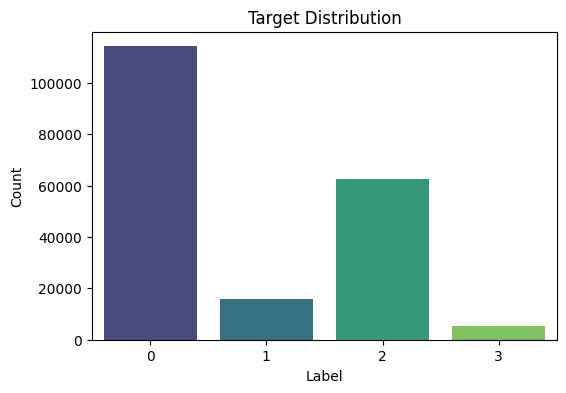

insights: The dataset is imbalanced.Label 0 has the highest number of samples.Label 2 also has a good amount of data.Labels 1 and 3 have very few samples.


In [4]:
# Plot distribution of target labels
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='label', palette='viridis')
plt.title("Target Distribution")
plt.xlabel("Label")

plt.ylabel("Count")
plt.show()

print("insights: The dataset is imbalanced.Label 0 has the highest number of samples.Label 2 also has a good amount of data.Labels 1 and 3 have very few samples.")

# 🔗 Correlation Analysis

Understanding relationships between numeric features.

Insight:
- Most features are weakly correlated
- Some moderate correlation between upvote/downvote

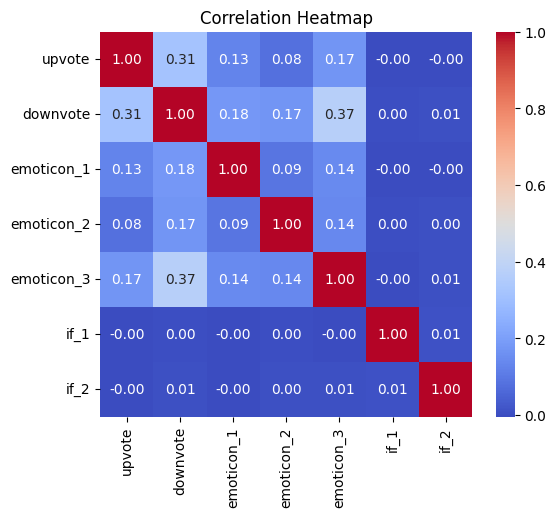

insights:  Most features have very low correlation with each other.upvote and downvote have some moderate correlation (~0.31).emoticon_3 and downvote show a slightly higher relation (~0.37).


In [5]:
# Plot correlation between numeric features
numeric_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']
plt.figure(figsize=(6, 5))
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print("insights:  Most features have very low correlation with each other.upvote and downvote have some moderate correlation (~0.31).emoticon_3 and downvote show a slightly higher relation (~0.37).")

# 📦 Outlier Detection

Using boxplots to identify extreme values in upvotes.

Observation:
- Heavy skew and extreme outliers present
- Requires capping (handled later)

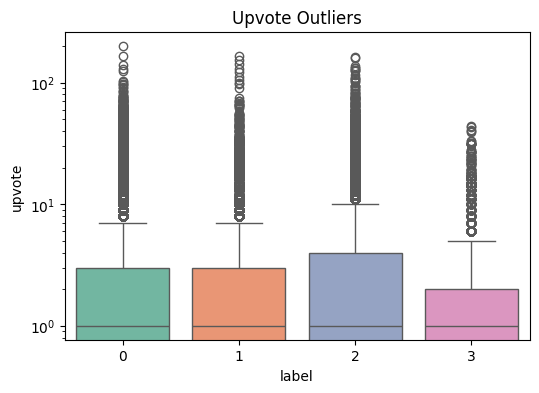

insights: There are many extreme values (outliers) in upvote. Most data is concentrated at low values, but some points are very high. This pattern is seen across all labels.


In [6]:
# Plot outliers in upvotes using boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='upvote', data=train_df, palette='Set2')
plt.title("Upvote Outliers")
plt.yscale('log')
plt.show()

print("insights: There are many extreme values (outliers) in upvote. Most data is concentrated at low values, but some points are very high. This pattern is seen across all labels.")

# 🧹 Data Cleaning & Preprocessing

Steps performed:
- Remove duplicates
- Fill missing categorical values
- Fill numeric values using median
- Cap outliers using IQR method
- Clean text (lowercase, remove links, symbols)

This ensures clean and consistent input data.

In [7]:
# Remove duplicate rows
train_df = train_df.drop_duplicates()

# Fill missing categorical values with 'None'
numeric_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']
cat_cols = ['race', 'religion', 'gender', 'disability']

train_df[cat_cols] = train_df[cat_cols].fillna('None')
test_df[cat_cols] = test_df[cat_cols].fillna('None')

# Fill missing numeric values with median
for col in numeric_cols:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)

# Limit extreme values using IQR method
for col in ['upvote', 'downvote']:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    train_df[col] = np.where(train_df[col] > upper_bound, upper_bound, train_df[col])
    test_df[col] = np.where(test_df[col] > upper_bound, upper_bound, test_df[col])

# Clean text data
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

train_df['clean_comment'] = train_df['comment'].apply(clean_text)
test_df['clean_comment'] = test_df['comment'].apply(clean_text)

# ⚙️ Feature Engineering

Transforming raw data into model-ready features:

- TF-IDF (word-level)
- TF-IDF (character-level)
- One-hot encoding (categorical)
- Scaling numeric features

All features are combined into a sparse matrix.

In [8]:
# Encode categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_cat_full = encoder.fit_transform(train_df[cat_cols].astype(str))
X_cat_test = encoder.transform(test_df[cat_cols].astype(str))

# Scale numeric features
scaler = MaxAbsScaler()
X_num_full = scaler.fit_transform(train_df[numeric_cols])
X_num_test = scaler.transform(test_df[numeric_cols])

# Convert text to TF-IDF features (word level)
tfidf = TfidfVectorizer(max_features=30000, min_df=2, ngram_range=(1, 2), stop_words='english', sublinear_tf=True)
X_text_full = tfidf.fit_transform(train_df['clean_comment'])
X_text_test = tfidf.transform(test_df['clean_comment'])

# Convert text to TF-IDF features (character level)
char_tfidf = TfidfVectorizer(max_features=15000, min_df=2, analyzer='char', ngram_range=(2, 4), sublinear_tf=True)
X_char_full = char_tfidf.fit_transform(train_df['clean_comment'])
X_char_test = char_tfidf.transform(test_df['clean_comment'])

# Combine all features
X_full = hstack([X_text_full, X_char_full, X_num_full, X_cat_full]).tocsr()
X_test_final = hstack([X_text_test, X_char_test, X_num_test, X_cat_test]).tocsr()

y_full = train_df['label']

# train-validation split
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

# Free memory
del X_text_full, X_text_test, X_char_full, X_char_test, X_num_full, X_num_test, X_cat_full, X_cat_test
gc.collect()

10794

# Models

# 🤖 Model 1: SGD Classifier

A fast linear model suitable for large sparse datasets.

Pros:
- Very fast
- Scales well

Cons:
- Lower accuracy compared to ensemble methods

In [9]:
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train, y_train)
print("SGD F1:", f1_score(y_val, sgd.predict(X_val), average='weighted'))
print("Insight: SGD is fast but performs slightly lower than ensemble models.")

SGD F1: 0.767295581703677
Insight: SGD is fast but performs slightly lower than ensemble models.


# 🤖 Model 2: Linear SVM

A strong linear classifier for text data.

Better margin optimization leads to improved performance over SGD.

In [10]:
# SVM
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)
print("SVM F1:", f1_score(y_val, svm.predict(X_val), average='weighted'))

SVM F1: 0.7895458635083948


# 🤖 Model 3: Logistic Regression

A robust baseline model with class balancing.

Hyperparameters tuned manually:
- C = 3.0
- solver = liblinear

In [11]:
# Logistic Regression baseline
lr = LogisticRegression(max_iter=2000, C=3.0, solver="liblinear", class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
print("LR F1:", f1_score(y_val, lr.predict(X_val), average='weighted'))

LR F1: 0.8083075124429412


# 🌲 Model 4: Random Forest

An ensemble model using multiple decision trees.

Captures non-linear relationships in data.

In [12]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("RF F1:", f1_score(y_val, rf.predict(X_val), average='weighted'))

RF F1: 0.8528844118579021


# 🚀 Model 5: LightGBM

Gradient boosting model that performs best on structured + text features.

Advantages:
- Handles large sparse data efficiently
- Captures complex patterns

In [13]:
# LightGBM model
lgbm = LGBMClassifier(
    n_estimators=600, learning_rate=0.04, max_depth=15, num_leaves=64,
    subsample=0.8, colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=0.5,
    class_weight='balanced', random_state=42, verbose=-1, n_jobs=2 
)
lgbm.fit(X_train, y_train)
print("LGBM F1:", f1_score(y_val, lgbm.predict(X_val), average='weighted'))

print("Insight: LightGBM performed best due to boosting.")

LGBM F1: 0.9175590008039645
Insight: LightGBM performed best due to boosting.


# 📊 Model Comparison (Train vs Validation)

We evaluate each model using **F1-score (weighted)** on:

- Training data → to check learning capacity  
- Validation data → to check generalization  

We also compute the **gap (Train - Validation)** to detect overfitting.

Interpretation:
- Small gap → good generalization  
- Large gap → overfitting  

In [14]:
# Comparison Table

comparison_df = pd.DataFrame({
    "Model": ["SGD","SVM","LR","RF","LGBM"],
    
    "Train F1": [
        f1_score(y_train, sgd.predict(X_train), average='weighted'),
        f1_score(y_train, svm.predict(X_train), average='weighted'),
        f1_score(y_train, lr.predict(X_train), average='weighted'),
        f1_score(y_train, rf.predict(X_train), average='weighted'),
        f1_score(y_train, lgbm.predict(X_train), average='weighted')
    ],
    
    "Val F1": [
        f1_score(y_val, sgd.predict(X_val), average='weighted'),
        f1_score(y_val, svm.predict(X_val), average='weighted'),
        f1_score(y_val, lr.predict(X_val), average='weighted'),
        f1_score(y_val, rf.predict(X_val), average='weighted'),
        f1_score(y_val, lgbm.predict(X_val), average='weighted')
    ]
})

comparison_df["Gap"] = comparison_df["Train F1"] - comparison_df["Val F1"]

comparison_df.sort_values(by="Val F1", ascending=False)

,Model,Train F1,Val F1,Gap
4,LGBM,0.962956,0.917559,0.045397
3,RF,1.000000,0.852884,0.147116
2,LR,0.888745,0.808308,0.080437
1,SVM,0.909029,0.789546,0.119483
0,SGD,0.784069,0.767296,0.016773


# 📈 Model Performance Visualization

Bar plot showing validation F1-scores of all models.

This helps in:
- Quickly identifying the best model
- Visually comparing performance differences

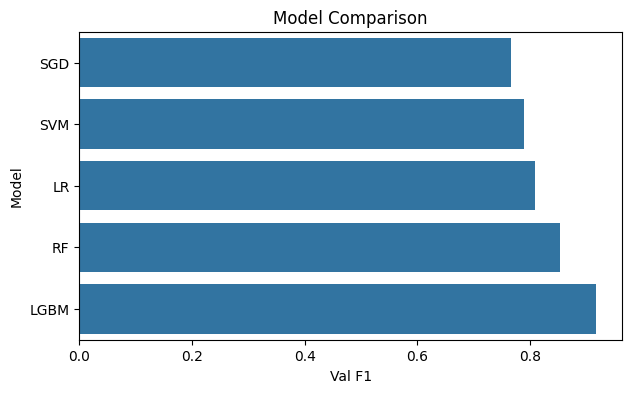

In [15]:
plt.figure(figsize=(7,4))
sns.barplot(data=comparison_df, x="Val F1", y="Model")
plt.title("Model Comparison")
plt.show()

# 🔗 Ensemble Learning (Weighted Averaging)

We combine predictions from top-performing models:
- Logistic Regression
- Random Forest
- LightGBM

Each model contributes with a weight:
- LR → lower weight
- RF → medium weight
- LGBM → highest weight (best performer)

Goal:
Improve overall performance by leveraging strengths of multiple models.

In [16]:
# Get prediction probabilities
p1 = lr.predict_proba(X_val)
p2 = rf.predict_proba(X_val)
p3 = lgbm.predict_proba(X_val)

pred = 0.2*p1 + 0.2*p2 + 0.6*p3
y_pred = lr.classes_[np.argmax(pred, axis=1)]
        
score = f1_score(y_val, y_pred, average='weighted')
print("Best F1:", score)

Best F1: 0.919696446344999


# 🏁 Final Model Training & Submission

Steps:
1. Retrain selected models on full dataset
2. Apply ensemble with chosen weights
3. Generate predictions on test data
4. Save submission file

This ensures maximum use of available data for best performance.

In [17]:
# Train final models on full dataset
lr.fit(X_full, y_full)
rf.fit(X_full, y_full)
lgbm.fit(X_full, y_full)

classes = lr.classes_

# Predict on test data
p1 = lr.predict_proba(X_test_final)
p2 = rf.predict_proba(X_test_final)
p3 = lgbm.predict_proba(X_test_final)

# Use best weights found earlier

final_test = (0.2*p1 + 0.2*p2 + 0.6*p3)

# Convert probabilities to correct labels
test_predictions = classes[np.argmax(final_test, axis=1)]

# Save submission file
if len(sample_sub) == len(test_predictions):
    sample_sub['label'] = test_predictions
    sample_sub.to_csv('submission.csv', index=False)
    
    print("Final submission file created successfully.")
    display(sample_sub.head())
else:
    print("Error: Prediction length mismatch")

Final submission file created successfully.


,ID,label
0,1,2
1,2,2
2,3,0
3,4,2
4,5,2
